In [1]:
import sys
sys.path.append("/home/export/sdurgut/scratch/alps/tracking_ALPs/")
sys.path.append('/home/export/sdurgut/scratch/alps/bkg/FORESEE/alp')
sys.path.append('/home/export/sdurgut/scratch/alps/bkg/FORESEE')
src_path = "../"
sys.path.append(src_path)
import numpy as np
from analysis.module_VBF import TRT_length, read_data, raw_to_events
import numpy as np
import math
import matplotlib.pyplot as plt
from src.foresee import Foresee, Utility, Model
import pandas as pd
from scripts.plotting.param_space_plotting_utils import calculate_n2g
from scripts.analysis_helpers.file_helpers import ma_to_name


In [2]:
hard_kl_sample = pd.read_csv('/home/export/sdurgut/scratch/alps/bkg/FORESEE/alp/kl_vbf_sample.csv')

In [4]:
hard_kl_sample.head()

,job,evt,j1_pt,j1_eta,j1_phi,j1_m,j2_pt,j2_eta,j2_phi,j2_m,...,kl_pt,kl_eta,kl_phi,kl_E,g1_pt,g1_eta,g1_phi,g2_pt,g2_eta,g2_phi
0,100000,64,135.546632,4.041822,2.867535,9.154664,127.218187,-0.958041,-0.485197,11.163347,...,1.221928,3.398687,2.405996,18.310146,0.342154,2.744286,2.655796,0.894403,3.553651,2.311284
1,100000,64,135.546632,4.041822,2.867535,9.154664,127.218187,-0.958041,-0.485197,11.163347,...,0.784339,-0.084590,-0.397019,0.931244,0.408616,0.503525,-0.437465,0.376421,-0.690306,-0.353112
2,100000,64,135.546632,4.041822,2.867535,9.154664,127.218187,-0.958041,-0.485197,11.163347,...,0.406246,-3.687002,1.644737,8.130012,0.371193,-3.762817,1.784212,0.064478,-1.344970,0.716872
3,100000,64,135.546632,4.041822,2.867535,9.154664,127.218187,-0.958041,-0.485197,11.163347,...,2.045088,3.769091,2.952689,44.344110,0.459268,3.695930,2.497951,1.644909,3.752773,3.075633
4,100000,64,135.546632,4.041822,2.867535,9.154664,127.218187,-0.958041,-0.485197,11.163347,...,0.185914,4.456389,-0.049879,8.027172,0.350576,3.317376,-0.298267,0.176392,3.585880,2.581221


In [5]:
hard_kl_pt = hard_kl_sample["kl_pt"]

In [6]:
SIGMA_HARD_PB = 3.6413e-3 * 1e9   # HardQCD (pThat>80) cross section, mb -> pb
N_HARD        = 20_000_000        # hard events generated (400 x 50k)
BR, L_FB      = 5.47e-4, 312
w_pb = SIGMA_HARD_PB / N_HARD     # 0.182 pb per kaon row

In [8]:
print(f"sigma(VBF K_L) = {len(hard_kl_pt)*w_pb:.3e} pb   (expect 1.13e6)")
print(f"N(VBF K_L->gg) @312/fb = {len(hard_kl_pt)*w_pb*L_FB*1000*BR:.3e}   (expect 1.93e8)")

sigma(VBF K_L) = 1.131e+06 pb   (expect 1.13e6)
N(VBF K_L->gg) @312/fb = 1.930e+08   (expect 1.93e8)


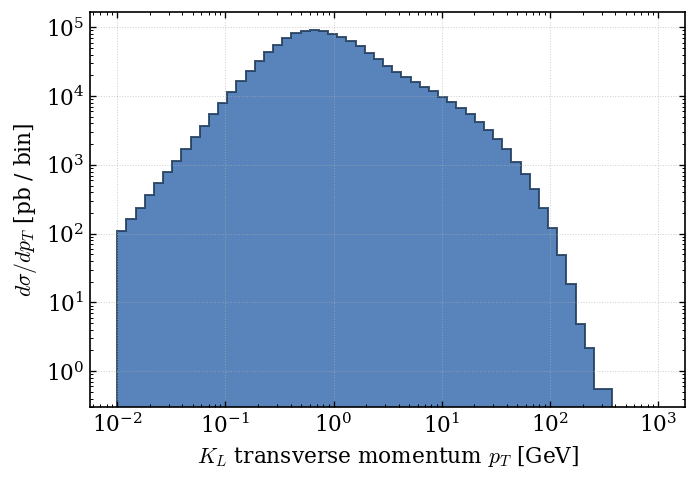

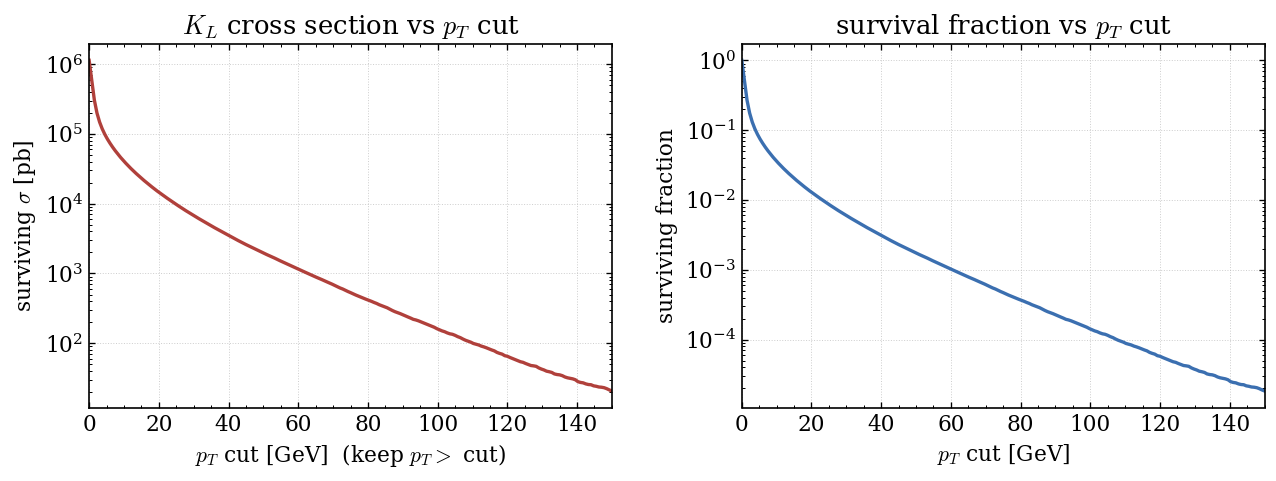

  pT cut         frac     sigma [pb]    N(K_L->gg) @ 312/fb
-----------------------------------------------------------
       0    1.000e+00      1.131e+06              1.930e+08
     0.5    6.793e-01      7.682e+05              1.311e+08
       1    3.999e-01      4.522e+05              7.717e+07
       2    1.988e-01      2.248e+05              3.836e+07
       5    7.823e-02      8.847e+04              1.510e+07
      10    3.582e-02      4.050e+04              6.912e+06
      20    1.289e-02      1.458e+04              2.488e+06
      30    5.995e-03      6.779e+03              1.157e+06
      40    3.113e-03      3.520e+03              6.007e+05
      50    1.738e-03      1.965e+03              3.354e+05
      60    1.020e-03      1.154e+03              1.969e+05
      70    6.110e-04      6.909e+02              1.179e+05


In [13]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# ---------- global publication style ----------
plt.rcParams.update({
    "font.size": 13,
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "axes.linewidth": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

# --- 1) pT distribution (as a cross section) ---
fig, ax = plt.subplots(figsize=(6, 4.2))
bins = np.logspace(-2, 3, 60)
ax.hist(hard_kl_pt, bins=bins, weights=np.full(len(hard_kl_pt), w_pb),
        histtype="stepfilled", color="#3b6fb0", edgecolor="#1f3b5c",
        alpha=0.85, linewidth=1.2)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$K_L$ transverse momentum $p_T$ [GeV]")
ax.set_ylabel(r"$d\sigma/dp_T$ [pb / bin]")
ax.grid(True, which="major", ls=":", lw=0.6, alpha=0.6)
fig.tight_layout()
fig.savefig("kl_pt_distribution.pdf")
plt.show()

# --- 2) surviving cross section vs a pT > cut requirement ---
pt_sorted = np.sort(hard_kl_pt)
cuts = np.linspace(0, 150, 201)
n_above = len(pt_sorted) - np.searchsorted(pt_sorted, cuts, side="right")
sigma_above = n_above * w_pb          # pb
frac        = n_above / len(pt_sorted)

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))

ax[0].plot(cuts, sigma_above, color="#b0403b", lw=2.0)
ax[0].set_yscale("log")
ax[0].set_xlabel(r"$p_T$ cut [GeV]  (keep $p_T >$ cut)")
ax[0].set_ylabel(r"surviving $\sigma$ [pb]")
ax[0].set_title(r"$K_L$ cross section vs $p_T$ cut")
ax[0].grid(True, which="major", ls=":", lw=0.6, alpha=0.6)

ax[1].plot(cuts, frac, color="#3b6fb0", lw=2.0)
ax[1].set_yscale("log")
ax[1].set_xlabel(r"$p_T$ cut [GeV]")
ax[1].set_ylabel("surviving fraction")
ax[1].set_title(r"survival fraction vs $p_T$ cut")
ax[1].grid(True, which="major", ls=":", lw=0.6, alpha=0.6)

for a in ax:
    a.set_xlim(cuts.min(), cuts.max())

fig.tight_layout()
fig.savefig("kl_survival_vs_ptcut.pdf")
plt.show()

# --- 3) table of a few representative cuts ---
header = f"{'pT cut':>8} {'frac':>12} {'sigma [pb]':>14} {'N(K_L->gg) @ 312/fb':>22}"
print(header)
print("-" * len(header))
for c in [0, 0.5, 1, 2, 5, 10, 20, 30, 40, 50, 60, 70]:
    n = (hard_kl_pt > c).sum()
    s = n * w_pb
    N = s * L_FB * 1000 * BR
    print(f"{c:>8} {n/len(hard_kl_pt):>12.3e} {s:>14.3e} {N:>22.3e}")